# Esercizio 3.3 - Addestramento Faster R-CNN con backbone ResNet-50

In questo notebook configuriamo e addestriamo **Faster R-CNN** trasferendo nel corpo del backbone i pesi della **ResNet-50 fine-tunata su GTSRB** nel notebook `02`. La FPN, la Region Proposal Network e le teste di detection mantengono invece l'inizializzazione COCO di torchvision.

Il tracciamento dei parametri, della loss di training e del **Mean Average Precision (mAP)** di validazione viene salvato sia in locale (CSV) sia su **Weights & Biases (WandB)**.

I componenti chiave sono:
- `src.detection_data.LitGTSRBDetectionDataModule`: caricatore di dati e coordinatore delle Bounding Box.
- `src.lightning_modules.LitFasterRCNN`: Modulo Lightning che incapsula la rete neurale, calcola la loss multi-task ed accumula le metriche di validazione.
- `config_detection.yaml`: File di configurazione degli iperparametri.

In [8]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import torch
import pytorch_lightning as pl
import wandb
from pytorch_lightning.loggers import WandbLogger, CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar
from omegaconf import OmegaConf

from src.detection_data import LitGTSRBDetectionDataModule
from src.lightning_modules import LitFasterRCNN
from src.utils import find_best_metric_checkpoint, set_seed

set_seed(42)

# Ottimizzazione per Tensor Cores
torch.set_float32_matmul_precision('medium')

In [9]:
# Caricamento della configurazione specifica per la detection
cfg = OmegaConf.load('config_detection.yaml')
print(OmegaConf.to_yaml(cfg))

dataset:
  data_dir: ../_data
  batch_size: 4
  num_workers: 4
model:
  name: faster_rcnn_resnet50
  num_classes: 44
  pretrained: true
  min_size: 800
  max_size: 1360
  backbone_checkpoint_dir: checkpoints
  backbone_checkpoint_prefix: resnet50_gtsrb
  backbone_checkpoint_metric: val_f1_score
  backbone_image_mean:
  - 0.5
  - 0.5
  - 0.5
  backbone_image_std:
  - 0.5
  - 0.5
  - 0.5
training:
  epochs: 10
  lr: 0.005
  optimizer: sgd
logging:
  project_name: DeepLearningApplicationLab1
  run_name: faster_rcnn_gtsrb_fpn_training
evaluation:
  checkpoint_dir: checkpoints/faster_rcnn_gtsrb_fpn
  checkpoint_prefix: faster_rcnn_resnet50_gtsrb
  checkpoint_metric: val_mAP_50



In [3]:
# Selezioniamo il miglior checkpoint della ResNet-50 fine-tunata su GTSRB nel notebook 02.
backbone_checkpoint_path = find_best_metric_checkpoint(
    checkpoint_dir=cfg.model.backbone_checkpoint_dir,
    filename_prefix=cfg.model.backbone_checkpoint_prefix,
    metric_name=cfg.model.backbone_checkpoint_metric,
)
cfg.model.backbone_checkpoint_path = str(backbone_checkpoint_path)
print(f"Backbone GTSRB selezionato: {backbone_checkpoint_path}")

# Inizializzazione del DataModule e del Modello
dm = LitGTSRBDetectionDataModule(
    cache_dir=cfg.dataset.data_dir,
    batch_size=cfg.dataset.batch_size,
    num_workers=cfg.dataset.num_workers
)

model = LitFasterRCNN(
    num_classes=cfg.model.num_classes,
    pretrained=cfg.model.pretrained,
    lr=cfg.training.lr,
    optimizer_name=cfg.training.optimizer,
    min_size=cfg.model.min_size,
    max_size=cfg.model.max_size,
    backbone_checkpoint_path=str(backbone_checkpoint_path),
    backbone_image_mean=list(cfg.model.backbone_image_mean),
    backbone_image_std=list(cfg.model.backbone_image_std),
)

Backbone GTSRB selezionato: checkpoints\resnet50_gtsrb-epoch=13-val_f1_score=0.999.ckpt


In [4]:
# Configurazione del monitoraggio su Weights & Biases.
wandb_logger = WandbLogger(
    project=cfg.logging.project_name,
    name=cfg.logging.run_name,
    config=OmegaConf.to_container(cfg, resolve=True),
    log_model=True
)

# Logger CSV locale in parallelo a WandB: le curve restano disponibili anche offline.
csv_logger = CSVLogger(save_dir="logs", name="faster_rcnn_training", version=0)

# Callback per salvare il miglior modello in base alla metrica mAP_50 di validazione
checkpoint_callback = ModelCheckpoint(
    monitor="val/mAP_50",
    mode="max",
    dirpath=cfg.evaluation.checkpoint_dir,
    filename="faster_rcnn_resnet50_gtsrb-{epoch:02d}-{val_mAP_50:.3f}",
    save_top_k=1
)

# Forziamo TQDM per risolvere i conflitti visivi di Rich in VS Code
progress_bar = TQDMProgressBar(refresh_rate=10)

In [5]:
# Inizializzazione del Trainer di PyTorch Lightning
trainer = pl.Trainer(
    max_epochs=cfg.training.epochs,
    accelerator="auto",
    devices=1,
    precision="16-mixed", # Abilita Automatic Mixed Precision (AMP)
    logger=[wandb_logger, csv_logger],
    callbacks=[checkpoint_callback, progress_bar],
    log_every_n_steps=5
)

# Avvio dell'addestramento.
print("Avvio addestramento Faster R-CNN...")
trainer.fit(model, datamodule=dm)

wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\franc\.netrc.


Avvio addestramento Faster R-CNN...


wandb: Currently logged in as: francescoberaldi01 (francescoberaldi01-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ FasterRCNN           │ 41.5 M │ train │     0 │
│ 1 │ val_map │ MeanAveragePrecision │      0 │ train │     0 │
└───┴─────────┴──────────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/loss_box_reg,▄█▄▃▂▂▁▁▁▁
train/loss_classifier,█▃▂▂▁▁▁▁▁▁
train/loss_epoch,█▄▂▂▁▁▁▁▁▁
train/loss_objectness,█▂▁▁▁▁▁▁▁▁
train/loss_rpn_box_reg,█▅▃▁▁▁▁▁▁▁
train/loss_step,█▃▅▃▃▃▄▂▂▂▃▂▃▃▃▁▂▂▃▂▂▂▁▂▂▁▂▂▂▂▃▂▃▁▂▂▂▃▂▂
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████
val/mAP,▁▂▄▆██████
val/mAP_50,▁▃▄▆██████
+1,...


## 3. Curve di Training

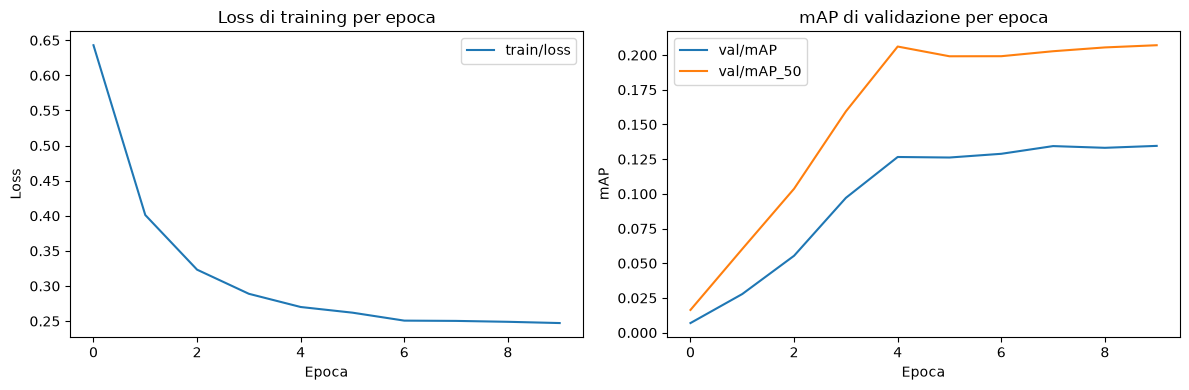

In [6]:
from src.utils import load_epoch_metrics
import matplotlib.pyplot as plt

metrics = load_epoch_metrics(
    "logs/faster_rcnn_training/version_0/metrics.csv",
    columns=("train/loss_epoch", "val/mAP", "val/mAP_50")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics.index, metrics["train/loss_epoch"], label="train/loss")
axes[0].set_title("Loss di training per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(metrics.index, metrics["val/mAP"], label="val/mAP")
axes[1].plot(metrics.index, metrics["val/mAP_50"], label="val/mAP_50")
axes[1].set_title("mAP di validazione per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("mAP")
axes[1].legend()

plt.tight_layout()
plt.show()

**Osservazioni**

- La loss di training scende da circa 0,64 a 0,25, indicando una convergenza regolare.
- La crescita principale avviene nelle prime cinque epoche: `val/mAP_50` raggiunge 0,206 all'epoca 4 e poi entra in plateau.
- Il checkpoint migliore viene salvato all'epoca 9 con `val/mAP_50 = 0,207`; una nuova valutazione del checkpoint produce `mAP = 0,1374` e `mAP_50 = 0,2105`. La lieve differenza dipende dal fatto che la validazione durante il fit usa mixed precision, mentre il controllo finale usa la precisione standard a 32 bit.

**Nota sull'evoluzione dell'esperimento.** In una prima prova era stato adattato soltanto il box predictor finale di Faster R-CNN; il modello ricaricato non produceva detection utili. Successivamente, il corpo ResNet-50 e' stato quindi sostituito con il backbone fine-tunato su GTSRB e collegato alla FPN. La prima validazione del nuovo modello alternava `train` ed `eval` nello stesso batch per calcolare insieme loss e mAP, rendendo la metrica non riproducibile dopo il caricamento. Calcolando invece la validazione esclusivamente in modalita' `eval`, il checkpoint ha restituito metriche coerenti con quelle osservate durante il training.

In [7]:
# Verifica finale del miglior checkpoint salvato durante il training.
best_model = LitFasterRCNN.load_from_checkpoint(
    checkpoint_callback.best_model_path,
    backbone_image_mean=list(cfg.model.backbone_image_mean),
    backbone_image_std=list(cfg.model.backbone_image_std),
)
validation_trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)
checkpoint_metrics = validation_trainer.validate(best_model, datamodule=dm, verbose=False)[0]
print(
    f"mAP checkpoint migliore={checkpoint_metrics['val/mAP']:.4f}; "
    f"mAP_50 checkpoint migliore={checkpoint_metrics['val/mAP_50']:.4f}"
)

c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

mAP checkpoint migliore=0.1374; mAP_50 checkpoint migliore=0.2105
